In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_11548\26603960.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/train.csv')


In [6]:
df.dtypes

Store             int64
DayOfWeek         int64
Date                str
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [23]:
df_test.dtypes

Id                 int64
Store              int64
DayOfWeek          int64
Date                 str
Open             float64
Promo              int64
StateHoliday         str
SchoolHoliday      int64
dtype: object

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [9]:
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [24]:
df_test.isnull().sum()

Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [10]:
print(df['Date'].min())
print(df['Date'].max())

2013-01-01 00:00:00
2015-07-31 00:00:00


In [25]:
df_test['Date'] = pd.to_datetime(df_test['Date'])
print(df_test['Date'].min())
print(df_test['Date'].max())

2015-08-01 00:00:00
2015-09-17 00:00:00


In [11]:
print(df['Store'].nunique())

1115


In [26]:
df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [27]:
df_test['Open'].value_counts()

Open
1.0    35093
0.0     5984
Name: count, dtype: int64

In [12]:
agg_df = df.groupby(['Date', 'Store'])['Sales'].sum().reset_index().sort_values(['Date', 'Store'])

In [14]:
agg_df.head(5)

,Date,Store,Sales
0,2013-01-01,1,0
1,2013-01-01,2,0
2,2013-01-01,3,0
3,2013-01-01,4,0
4,2013-01-01,5,0


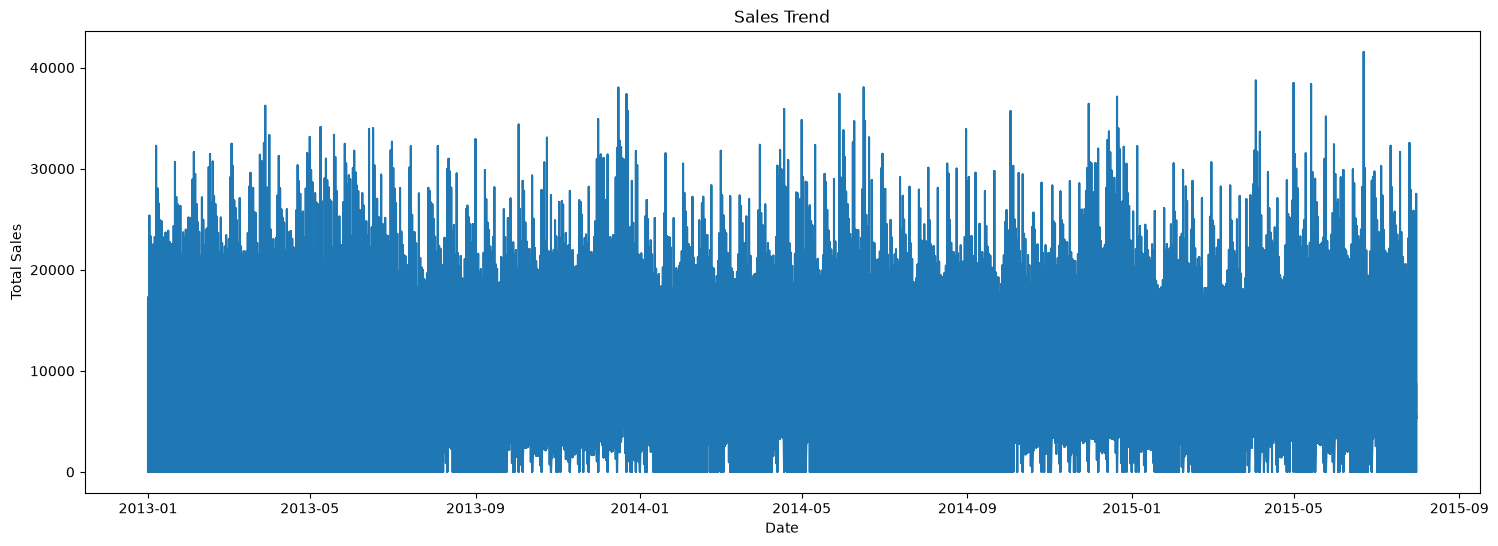

In [21]:
plt.figure(figsize=(18, 6))
plt.plot(agg_df['Date'], agg_df['Sales'])
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Trend')
plt.show()

In [19]:
total_sales = agg_df.pivot(index='Date', columns='Store', values='Sales')

In [16]:
total_sales.head(5)

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,5530.0,4422.0,6823.0,9941.0,4253.0,6089.0,8244.0,5419.0,4903.0,4812.0,...,5099.0,3955.0,6220.0,4576.0,4126.0,5097.0,10797.0,6218.0,20642.0,3697.0
2013-01-03,4327.0,4159.0,5902.0,8247.0,3465.0,5398.0,7231.0,4842.0,4602.0,4675.0,...,4330.0,3151.0,4779.0,3654.0,3508.0,4579.0,8716.0,5563.0,18463.0,4297.0
2013-01-04,4486.0,4484.0,6069.0,8290.0,4456.0,6092.0,7758.0,4059.0,4798.0,5114.0,...,3956.0,3990.0,5491.0,3596.0,3933.0,4640.0,9788.0,5524.0,18371.0,4540.0
2013-01-05,4997.0,2342.0,4523.0,10338.0,1590.0,3872.0,5218.0,2337.0,4254.0,4256.0,...,2624.0,5128.0,2113.0,2897.0,3156.0,3325.0,9513.0,5194.0,18856.0,4771.0
